In [25]:
# %pip install -q numpy pandas scikit-learn matplotlib

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# **Gaussian Bayes**

In [27]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.datasets import make_classification, make_moons, make_circles

def generate_data(dataset):
  if dataset == 'iris':
    iris = load_iris()

    # Filter for 'setosa' (0) and 'versicolor' (1) species
    # The original dataset has target names: ['setosa', 'versicolor', 'rbf_kernel']
    setosa_versicolor_indices = np.where((iris.target == 0) | (iris.target == 1))
    X = iris.data[setosa_versicolor_indices]
    y = iris.target[setosa_versicolor_indices]

    # Select 'sepal length (cm)' (index 0) and 'sepal width (cm)' (index 1) as features
    X = X[:, [0, 1]]

  elif dataset == 'circles':
    X, y = make_moons(n_samples=10000, noise=0.1,random_state=42)
  elif dataset == 'moons':
    X, y = make_moons(n_samples=10000, noise=0.2,random_state=42)

  elif dataset == 'blob':
    X,y = make_classification(
        n_samples=10000,
        n_features=2,
        n_redundant=0,
        n_clusters_per_class=1,
        class_sep=1.5,       # Controls how far apart the two clusters are
        random_state=42
    )
  return X,y

X,y = generate_data('iris')

## **Quadratic Bayes Discriminator**


$P(Y \vert{} X) \propto P(X \vert{} Y) P(Y)$

Here we can observe that the prior is on the target class, not on the parameters of the model. So the prior is not Gaussian in this case unlike how it is in Bayesian Regression.

For all the code we are going to see below we are to apply the Bayes' Classification for binary classification problem. We try to estimate the boundary between the datapoints of two classes.

Basically we are solving the equation given below:

$ P(X \vert{} Y=0) P(Y=0)  = P(X \vert{} Y=1) P(Y=1)$

On solving we get a hyperplane equation.

This helps us in two ways:

- We can predict the class easily by plugging in the value of x in the hyperplane
- We can solve the hyperplane to find the set of points which the model is finding difficult to predict.

#### **We identify the boundary which divides the two classes by equating posterior for both classes.**



In [28]:
def compute_coeficients(X,y):
  mean_setosa = np.mean(X[y == 0], axis=0)
  mean_versicolor = np.mean(X[y == 1], axis=0)

  covariance_setosa = np.cov(X[y == 0].T)
  covariance_versicolor = np.cov(X[y == 1].T)

  # Uncomment this for the assumption all features have same variance
  #covariance_setosa = covariance_versicolor = 0.5 * (covariance_setosa + covariance_versicolor)
  determinant_setosa = np.linalg.det(covariance_setosa)
  determinant_versicolor = np.linalg.det(covariance_versicolor)

  prior_setosa = np.sum(y == 0) / len(y)
  prior_versicolor = np.sum(y == 1) / len(y)

  C_consts = 2*np.log(prior_setosa/prior_versicolor) + np.log(determinant_versicolor/determinant_setosa)
  C_setosa = mean_setosa.T @ np.linalg.inv(covariance_setosa) @ mean_setosa
  C_versicolor = mean_versicolor.T @ np.linalg.inv(covariance_versicolor) @ mean_versicolor

  C = C_consts - C_setosa + C_versicolor
  A = np.linalg.inv(covariance_setosa) - np.linalg.inv(covariance_versicolor)
  B = 2*(mean_setosa @ np.linalg.inv(covariance_setosa) - mean_versicolor @ np.linalg.inv(covariance_versicolor))

  return A,B,C

def predict(x):
  score = x.T@A@x - x.T@B - C
  if score < 0:
    return 0
  else:
    return 1

A =
 [[13.74749936 -8.91767149]
 [-8.91767149  2.54614848]]


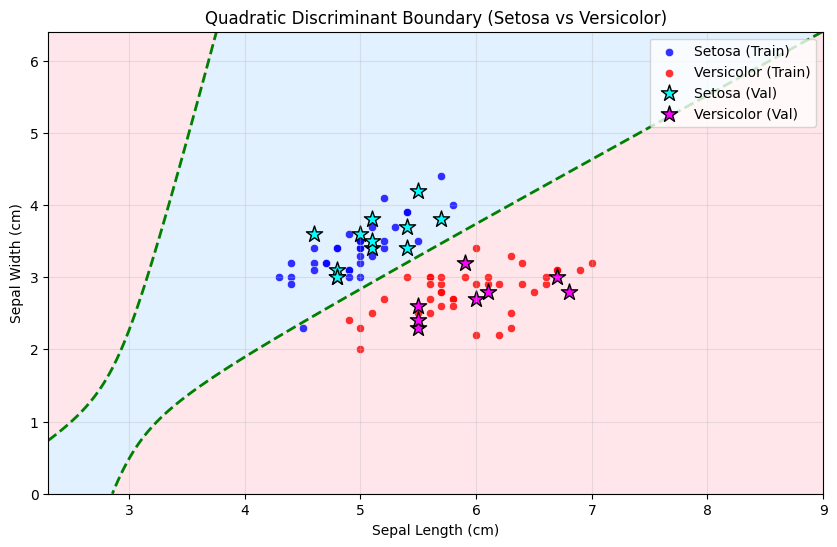

Validation Accuracy: 1.0000 (100.00%)


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train
A, B, C = compute_coeficients(X_train, y_train)
A = np.asarray(A, dtype=float)
B = np.asarray(B, dtype=float)
print("A =\n", A)

# 3. Plotting
plt.figure(figsize=(10, 6))

# 4. Decision boundary + region grid
pad_x, pad_y = 2.0, 2.0
x_min, x_max = X[:, 0].min() - pad_x, X[:, 0].max() + pad_x
y_min, y_max = X[:, 1].min() - pad_y, X[:, 1].max() + pad_y
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))

grid = np.stack([xx.ravel(), yy.ravel()], axis=1)
quad_term = np.einsum('ni,ij,nj->n', grid, A, grid)
lin_term  = grid @ B
Z = (quad_term - lin_term - C).reshape(xx.shape)

# --- Figure out which sign corresponds to which class ---
# Evaluate the score at the mean of each class's training points, then
# use that to decide the color mapping instead of hardcoding a sign.
mean0 = X_train[y_train == 0].mean(axis=0)
mean1 = X_train[y_train == 1].mean(axis=0)
score0 = mean0 @ A @ mean0 - mean0 @ B - C
score1 = mean1 @ A @ mean1 - mean1 @ B - C

# If class 0 (Setosa) sits on the negative side, region_labels matches
# Z<0 -> class 0 directly; otherwise we flip it.
setosa_is_negative = score0 < score1

# Build a class-label grid (0 or 1) from Z using the correct sign convention
if setosa_is_negative:
    region_class = (Z > 0).astype(int)   # 0 where Z<0 (Setosa), 1 where Z>0
else:
    region_class = (Z < 0).astype(int)   # flip if convention is reversed

# Two flat background colors, very light so points stay visible
region_cmap = plt.matplotlib.colors.ListedColormap(['#cfe8ff', '#ffd6de'])  # light blue, light red/pink
plt.contourf(xx, yy, region_class, levels=[-0.5, 0.5, 1.5], cmap=region_cmap, alpha=0.6)

# The actual boundary line
plt.contour(xx, yy, Z, levels=[0], colors='green', linewidths=2, linestyles='dashed')

# Plot Training Data
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1],
            color='blue', label='Setosa (Train)', marker='o', alpha=0.8, edgecolor='white', linewidth=0.5)
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1],
            color='red', label='Versicolor (Train)', marker='o', alpha=0.8, edgecolor='white', linewidth=0.5)

# Plot Validation Data
plt.scatter(X_val[y_val == 0][:, 0], X_val[y_val == 0][:, 1],
            color='cyan', label='Setosa (Val)', marker='*', s=150, edgecolor='black')
plt.scatter(X_val[y_val == 1][:, 0], X_val[y_val == 1][:, 1],
            color='magenta', label='Versicolor (Val)', marker='*', s=150, edgecolor='black')

plt.title('Quadratic Discriminant Boundary (Setosa vs Versicolor)')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Validation Accuracy ---
def predict(X, A, B, C, setosa_is_negative):
    scores = np.einsum('ni,ij,nj->n', X, A, X) - X @ B - C
    if setosa_is_negative:
        return (scores > 0).astype(int)   # class 1 where score>0, else 0
    else:
        return (scores < 0).astype(int)

y_val_pred = predict(X_val, A, B, C, setosa_is_negative)
accuracy = np.mean(y_val_pred == y_val)
print(f"Validation Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

In [30]:
# 5. Extract and print the algebraic equation of the boundary
# The boundary is where the score is 0: (x^T * A * x) - (x^T * B) - C = 0
# Expanding this matrix multiplication gives a standard conic section equation:
# A_00*x1^2 + (A_01 + A_10)*x1*x2 + A_11*x2^2 - B_0*x1 - B_1*x2 - C = 0

# Extract individual coefficients
coeff_x1_sq = A[0, 0]
coeff_x2_sq = A[1, 1]
coeff_x1_x2 = A[0, 1] + A[1, 0]
coeff_x1 = -B[0]
coeff_x2 = -B[1]
coeff_const = -C

# Format the signs and values for readable CLI output
def fmt(val, is_first=False):
    if is_first:
        return f"{val:.4f}"
    return f"+ {val:.4f}" if val >= 0 else f"- {abs(val):.4f}"

equation = (
    f"{fmt(coeff_x1_sq, True)}*x1^2 "
    f"{fmt(coeff_x1_x2)}*x1*x2 "
    f"{fmt(coeff_x2_sq)}*x2^2 "
    f"{fmt(coeff_x1)}*x1 "
    f"{fmt(coeff_x2)}*x2 "
    f"{fmt(coeff_const)} = 0"
)

print("\nAlgebraic Equation of the Decision Boundary:")
print(equation)


Algebraic Equation of the Decision Boundary:
13.7475*x1^2 - 17.8353*x1*x2 + 2.5461*x2^2 - 61.1039*x1 + 46.4909*x2 + 62.3940 = 0


# **Naive Bayes**

The only difference in the formulation of our previous problem is that we now assume the features of our input are conditionally independent.

Mathematically, this means the covariance between any two distinct features is zero:


$$cov(x_j, x_k) = 0$$

Because of this independence, $P(x_j \mid Y=0)$ and $P(x_k \mid Y=0)$ are independent events. Instead of calculating a complex joint probability, we can simply multiply the individual probabilities together to get the intersection of the events.

When evaluating the decision boundary where the probabilities of both classes are equal, the final equation using the product rule ($\prod$) over $d$ features is:

$$P(Y=0) \prod_{j=1}^{d} P(x_j \mid Y=0) = P(Y=1) \prod_{j=1}^{d} P(x_j \mid Y=1)$$

In [31]:
import numpy as np

def compute_coeficients_nb(X, y):
    mean_setosa = np.mean(X[y == 0], axis=0)
    mean_versicolor = np.mean(X[y == 1], axis=0)

    var_setosa = np.var(X[y == 0], axis=0, ddof=1)
    var_versicolor = np.var(X[y == 1], axis=0, ddof=1)

    std_setosa = np.sqrt(var_setosa)
    std_versicolor = np.sqrt(var_versicolor)

    prior_setosa = np.sum(y == 0) / len(y)
    prior_versicolor = np.sum(y == 1) / len(y)

    A = 0.5 * np.diag((1 / var_setosa) - (1 / var_versicolor))

    B = (mean_setosa / var_setosa) - (mean_versicolor / var_versicolor)

    constant_sum_terms = np.sum(
        (mean_setosa**2 / (2 * var_setosa))
        - (mean_versicolor**2 / (2 * var_versicolor))
        + np.log(std_versicolor / std_setosa)
    )

    constant_prior_term = np.log(prior_setosa / prior_versicolor)

    C = -1*(constant_sum_terms + constant_prior_term)

    return A, B, C

def predict(x, A, B, C):
    score = x.T @ A @ x - x.T @ B - C
    if score < 0:
        return 0
    else:
        return 1

A =
 [[ 2.09730974  0.        ]
 [ 0.         -1.54621952]]


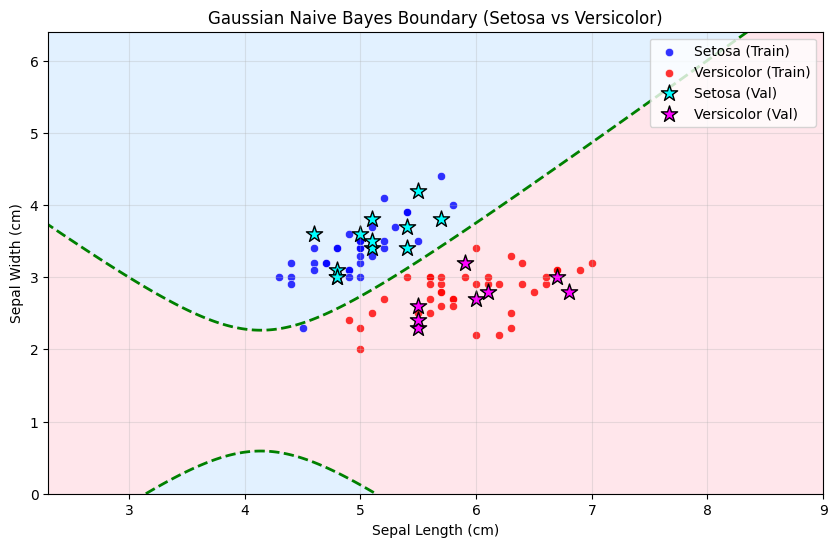

Validation Accuracy: 1.0000 (100.00%)


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

def compute_coeficients_nb(X, y):
    mean_setosa = np.mean(X[y == 0], axis=0)
    mean_versicolor = np.mean(X[y == 1], axis=0)

    var_setosa = np.var(X[y == 0], axis=0, ddof=1)
    var_versicolor = np.var(X[y == 1], axis=0, ddof=1)

    # Uncomment this for the assumption all features have same variance
    # var_setosa = var_versicolor = 0.5 * (var_setosa + var_versicolor)

    std_setosa = np.sqrt(var_setosa)
    std_versicolor = np.sqrt(var_versicolor)

    prior_setosa = np.sum(y == 0) / len(y)
    prior_versicolor = np.sum(y == 1) / len(y)

    A = 0.5 * np.diag((1 / var_setosa) - (1 / var_versicolor))
    B = (mean_setosa / var_setosa) - (mean_versicolor / var_versicolor)

    constant_sum_terms = np.sum(
        (mean_setosa**2 / (2 * var_setosa))
        - (mean_versicolor**2 / (2 * var_versicolor))
        + np.log(std_versicolor / std_setosa)
    )

    constant_prior_term = np.log(prior_setosa / prior_versicolor)
    C = -(constant_sum_terms + constant_prior_term)

    return A, B, C

# 1. Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train (Using Naive Bayes now)
A, B, C = compute_coeficients_nb(X_train, y_train)
A = np.asarray(A, dtype=float)
B = np.asarray(B, dtype=float)
print("A =\n", A)

# 3. Plotting
plt.figure(figsize=(10, 6))

# 4. Decision boundary + region grid
pad_x, pad_y = 2.0, 2.0
x_min, x_max = X[:, 0].min() - pad_x, X[:, 0].max() + pad_x
y_min, y_max = X[:, 1].min() - pad_y, X[:, 1].max() + pad_y
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))

grid = np.stack([xx.ravel(), yy.ravel()], axis=1)
quad_term = np.einsum('ni,ij,nj->n', grid, A, grid)
lin_term  = grid @ B
Z = (quad_term - lin_term - C).reshape(xx.shape)

# --- Figure out which sign corresponds to which class ---
mean0 = X_train[y_train == 0].mean(axis=0)
mean1 = X_train[y_train == 1].mean(axis=0)
score0 = mean0 @ A @ mean0 - mean0 @ B - C
score1 = mean1 @ A @ mean1 - mean1 @ B - C

setosa_is_negative = score0 < score1

# Build a class-label grid
if setosa_is_negative:
    region_class = (Z > 0).astype(int)
else:
    region_class = (Z < 0).astype(int)

# Background colors
region_cmap = plt.matplotlib.colors.ListedColormap(['#cfe8ff', '#ffd6de'])
plt.contourf(xx, yy, region_class, levels=[-0.5, 0.5, 1.5], cmap=region_cmap, alpha=0.6)

# The actual boundary line
plt.contour(xx, yy, Z, levels=[0], colors='green', linewidths=2, linestyles='dashed')

# Plot Training Data
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1],
            color='blue', label='Setosa (Train)', marker='o', alpha=0.8, edgecolor='white', linewidth=0.5)
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1],
            color='red', label='Versicolor (Train)', marker='o', alpha=0.8, edgecolor='white', linewidth=0.5)

# Plot Validation Data
plt.scatter(X_val[y_val == 0][:, 0], X_val[y_val == 0][:, 1],
            color='cyan', label='Setosa (Val)', marker='*', s=150, edgecolor='black')
plt.scatter(X_val[y_val == 1][:, 0], X_val[y_val == 1][:, 1],
            color='magenta', label='Versicolor (Val)', marker='*', s=150, edgecolor='black')

# Updated Title
plt.title('Gaussian Naive Bayes Boundary (Setosa vs Versicolor)')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Validation Accuracy ---
def predict_eval(X, A, B, C, setosa_is_negative):
    scores = np.einsum('ni,ij,nj->n', X, A, X) - X @ B - C
    if setosa_is_negative:
        return (scores > 0).astype(int)
    else:
        return (scores < 0).astype(int)

y_val_pred = predict_eval(X_val, A, B, C, setosa_is_negative)
accuracy = np.mean(y_val_pred == y_val)
print(f"Validation Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# **Using Scikit-Learn**

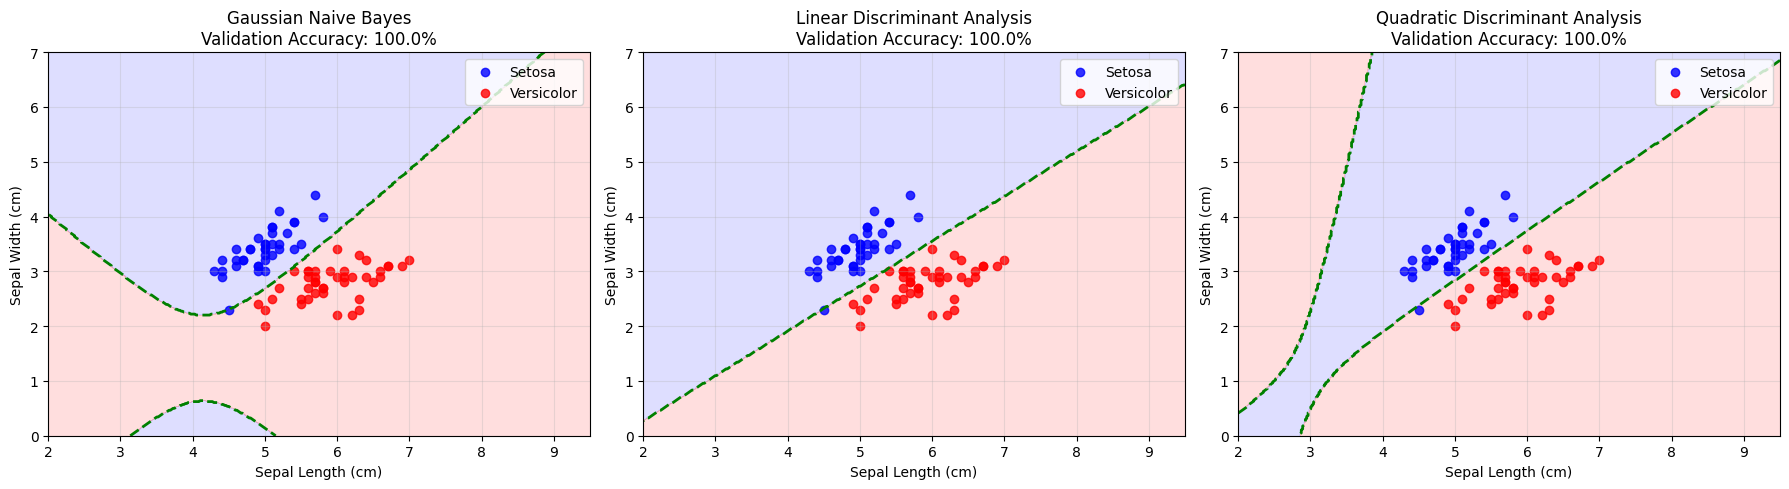

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# 1. Load and filter Iris data (Setosa vs Versicolor, features 0 and 1)
iris = load_iris()
idx = np.where((iris.target == 0) | (iris.target == 1))
X = iris.data[idx][:, [0, 1]]
y = iris.target[idx]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Define scikit-learn models
models = {
    "Gaussian Naive Bayes": GaussianNB(),
    "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
    "Quadratic Discriminant Analysis": QuadraticDiscriminantAnalysis(),
}

# 3. Create meshgrid with EXTENDED limits to see the true geometry
x_min, x_max = 2.0, 9.5
y_min, y_max = 0.0, 7.0
# Increased resolution to 400x400 for smoother curved boundaries
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400)
)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# 4. Train and plot side-by-side boundaries
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train, y_train)
    Z = model.predict(grid_points).reshape(xx.shape)

    # Plot decision regions
    ax.contourf(xx, yy, Z, alpha=0.15, cmap="bwr")
    ax.contour(xx, yy, Z, levels=[0.5], colors="green", linewidths=2.0, linestyles='dashed')

    # Plot data points
    ax.scatter(
        X_train[y_train == 0, 0],
        X_train[y_train == 0, 1],
        color="blue",
        label="Setosa",
        alpha=0.8,
    )
    ax.scatter(
        X_train[y_train == 1, 0],
        X_train[y_train == 1, 1],
        color="red",
        label="Versicolor",
        alpha=0.8,
    )

    acc = model.score(X_val, y_val) * 100
    ax.set_title(f"{name}\nValidation Accuracy: {acc:.1f}%")
    ax.set_xlabel("Sepal Length (cm)")
    ax.set_ylabel("Sepal Width (cm)")

    # Enforce the extended axis limits on the plot
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()